## Limpieza, Escalamiento y Transformación de Datos

Cuando estas en el EDA solamente se utiliza solamene el train set, en esta parte se analiza:

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
PATH_CALIFORNIA = "/content/drive/MyDrive/machine_learning/california_housing/"
df_california_housing = pd.read_csv(f"{PATH_CALIFORNIA}housing.csv")

In [6]:
df_california_housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
df_california_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


> Ojo si hay valores nulos los algoritmos no van a funcionar como se esperan

Hay 3 formas de solucionarlo:
- Eliminar las filas donde sean nulos. (No es recomendable ya que podemos eliminar datos importantes)
- Eliminar la caracteristicas completa. (No es recomendable ya que podemos eliminar datos importantes)
- Inyectar datos calculados en esos elementos (Recomendado) se le conoce como data imputation.

Conceptos:
- drop elimina la columna target
- .copy() evita SettingWithCopyWarning

In [8]:
TARGET = 'median_house_value'
X = df_california_housing.drop(TARGET, axis=1)
y = df_california_housing[TARGET].copy()

print(f'X shape : {X.shape}  → {X.columns.tolist()}')
print(f'y shape : {y.shape}  → {TARGET}')

X shape : (20640, 9)  → ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
y shape : (20640,)  → median_house_value


## ¿Qué es la inputación de datos?

Proceso en donde se reemplaza valores faltantes con estimaciones razonables. 

Cuando recolectas datos del mundo real, siempre hay huecos. Alguien no respondió una encuesta, un sensor falló, un campo era opcional. Esos huecos son NaN (Not a Number) en tu DataFrame.La alternativa obvia sería eliminar las filas con NaN, pero eso puede costarte el 20% de tus datos, y el modelo que entrenes con datos incompletos aprende distribuciones sesgadas.La imputación dice: "no eliminamos, estimamos".

Tipos de inputación:

- Simple: Se utiliza para reemplazar el valor faltante utilizando unicamente datos de esa columna.

Tiene 3 métodos:
1. Mean imputation: Reemplaza con la media de la columna. Para distribuciones simétricas, si la campana es simetrica la media y la mediana son casi iguales, utilizar la media.
2. Median Imputation: Si hay cola larga hacia la derecha (outliers, como salarios o precios de casas) no se va a ver tan afectada → la media se infla por esos extremos → usa mediana
3. Mode Imputation: Para variables categoricas reemplazar con el valor más frecuente.

- Multivariante o Basada en modelo: Usa otras columnas como predictores para estimar valores faltantes.
Se utiliza cuando las columnas están fuertemente correlacionadas con otras features.

- Imputación avanzada: va a crear modelos como regresión lineal para predecir los valores faltantes.

## Selección de imputación

### Por tipos de variables

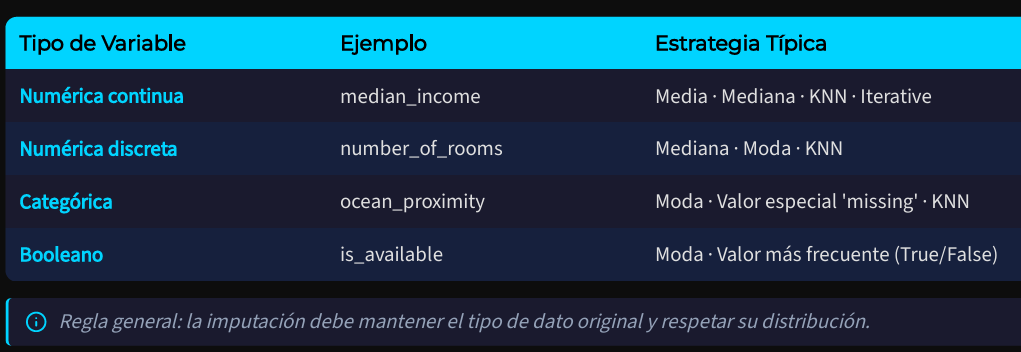

### Por distribución


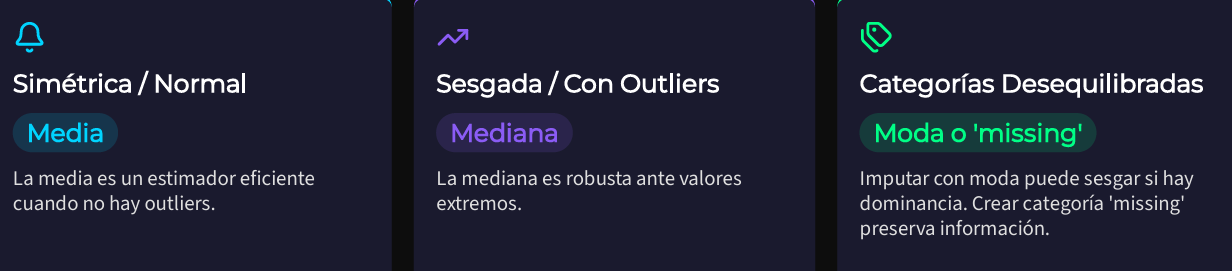

### Por porcentaje de valores faltantes y correlación con otras columnas

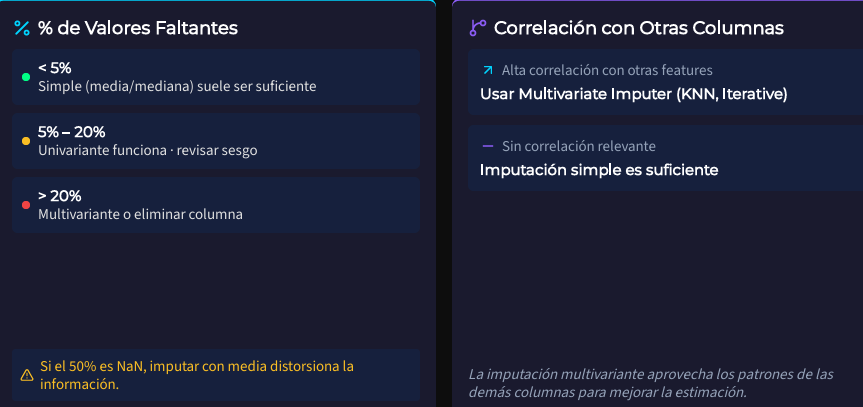

En este caso le falta datos a total **total_bedrooms** así que se analizará

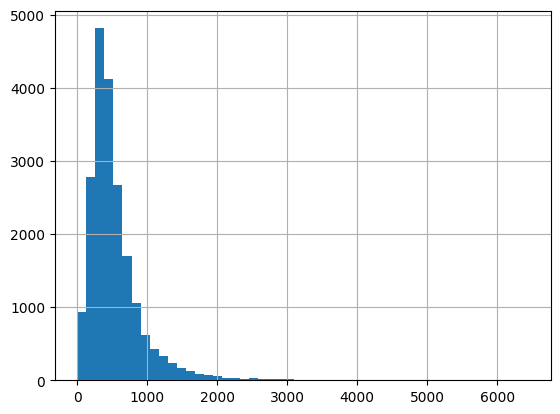

In [9]:
df_california_housing['total_bedrooms'].hist(bins=50)
plt.show()

Para eso vamos a utilizar imputación simple ya que solo trabajamos con esa columna y además hay valores atipicos. Por eso vamos a trabajar con la mediana.

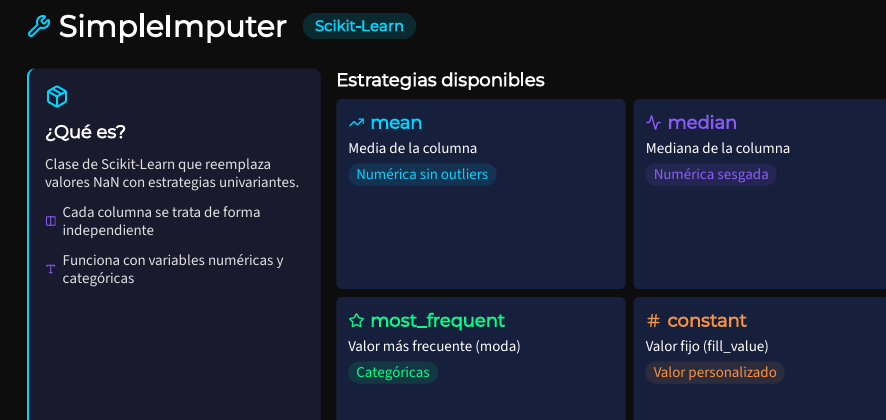

Esto de inputación lo realiza Scikit learn ya nos facilita esa parte. Por eso nos debemos concentrar en tomar las mejores decisiones para el dataset que estamos trabajando.

In [10]:
from sklearn.impute import SimpleImputer

imputer  = SimpleImputer(strategy="median")

In [11]:
# Seleccionar las categorias numericas
housing_num = X.select_dtypes(include=[np.number])

In [12]:
# Calculo de estadisticas de inputación de mediana columna por columna
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [13]:
# Se observa la mediana de cada columna
imputer.statistics_

array([-118.49  ,   34.26  ,   29.    , 2127.    ,  435.    , 1166.    ,
        409.    ,    3.5348])

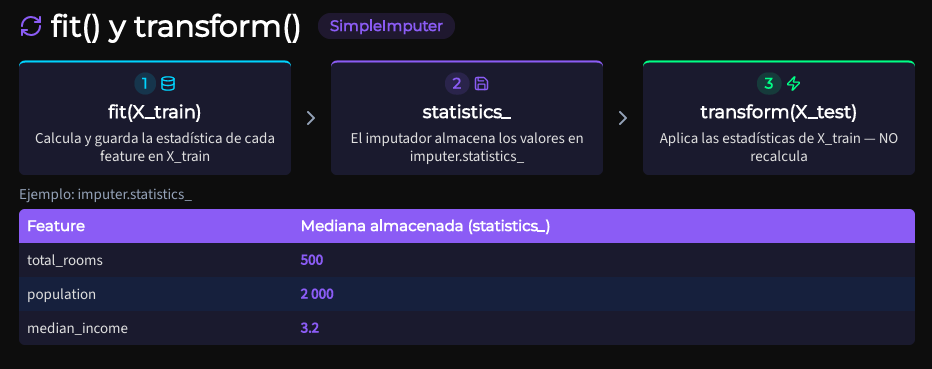

En la parte de imputar más adelante en el dataset de pruebas, se va a utilizar los valores estadisticos que se definio en el primer paso quedan almacenados.

In [14]:
# Reemplaza esa columna que le falta valor
X = imputer.transform(housing_num)
X

array([[-1.2223e+02,  3.7880e+01,  4.1000e+01, ...,  3.2200e+02,
         1.2600e+02,  8.3252e+00],
       [-1.2222e+02,  3.7860e+01,  2.1000e+01, ...,  2.4010e+03,
         1.1380e+03,  8.3014e+00],
       [-1.2224e+02,  3.7850e+01,  5.2000e+01, ...,  4.9600e+02,
         1.7700e+02,  7.2574e+00],
       ...,
       [-1.2122e+02,  3.9430e+01,  1.7000e+01, ...,  1.0070e+03,
         4.3300e+02,  1.7000e+00],
       [-1.2132e+02,  3.9430e+01,  1.8000e+01, ...,  7.4100e+02,
         3.4900e+02,  1.8672e+00],
       [-1.2124e+02,  3.9370e+01,  1.6000e+01, ...,  1.3870e+03,
         5.3000e+02,  2.3886e+00]])

In [15]:
# Creamos un dataframe con todos los valores completos
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

In [16]:
housing_tr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


## Columnas categoricas

Hay un problema con el tipo de dato object en pandas, si no utilizamos un tipo de dato categorico el se va a ir a un tipo de datos object pero cada uno de eso va a consumir un monton de memoria.

Pandas no trabaja bien con los string ya que esto va a ser un objeto de python y es bastante pesado.

Recordando que los algoritmos de machine learning no le gusta trabajar con String si no con valores númericas aunque hay varias estrategias como PCA, MCA, entre otros hibridos que salen en Papers que luego se le dedicara un sección especializada a eso cuando se domine bien los fundamentos.

In [17]:
housing_cat = df_california_housing[["ocean_proximity"]]

In [18]:
housing_cat.value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


## Tipos de Estrategias

### Ordinal Encoder

Esto lo que va a ser convierte atributos categóricos en valores numéricos enteros.
- Cada categoría recibe un número entero único.
- Funciona bien cuando tiene un orden natural como malo(0), bueno(1) o excelente(2) y se le asigna números.

In [19]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded  = ordinal_encoder.fit_transform(housing_cat)

In [20]:
housing_cat_encoded[:8]

array([[3.],
       [3.],
       [3.],
       [3.],
       [3.],
       [3.],
       [3.],
       [3.]])

In [21]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

### Problema con el OrdinalEncoder

Cuando las categorías no tienen orden natural como ["INLAND", "ISLAND", "NEAR BAY"] el OrdinalEncoder crea una relación matemática falsa entre ellas.

### One-Hot Encoding

Para eso existe el OneHotEncoder que en lugar de asignar números secuenciales, crea una columna binaria 0 y 1 por cada categoría evitando cualquier relación matemática inventada.

Teniendo una categoria completamente independiente

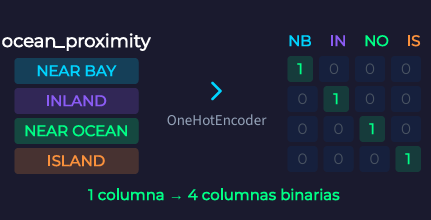

In [22]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(
    sparse_output=False,  # Retorna un array denso en lugar de una matriz dispersa (sparse)
    handle_unknown="ignore"  # Si aparece una categoría nueva, no lanza error sino que la completa con 0s
)

housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [23]:
housing_cat_1hot.shape


(20640, 5)

In [24]:
housing_cat_1hot

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [25]:

housing_cat_encoded = pd.DataFrame(
    housing_cat_1hot,
    columns=cat_encoder.get_feature_names_out(),
    index=housing_cat.index
)

In [26]:
housing_cat_encoded

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...
20635,0.0,1.0,0.0,0.0,0.0
20636,0.0,1.0,0.0,0.0,0.0
20637,0.0,1.0,0.0,0.0,0.0
20638,0.0,1.0,0.0,0.0,0.0


## Feature Scaling

Transformación matemática que ajusta la escala de variables numéricas sin alterar su información.

### ¿Por qué es necesario?
Evitar que variables con rangos grandes dominen a otras en los cálculos del modelo.
El problema surge cuando distintas features tienen órdenes de magnitud muy diferentes.

### Algoritmos sensibles a la escala
- **KNN** — calcula distancias euclidianas entre puntos
- **K-Means** — determina centroides basándose en distancias
- **Gradient Descent** — afecta la velocidad de convergencia
- **Redes Neuronales** — impacta en las funciones de activación
- **PCA** — identifica direcciones de máxima varianza

### Problema de escala

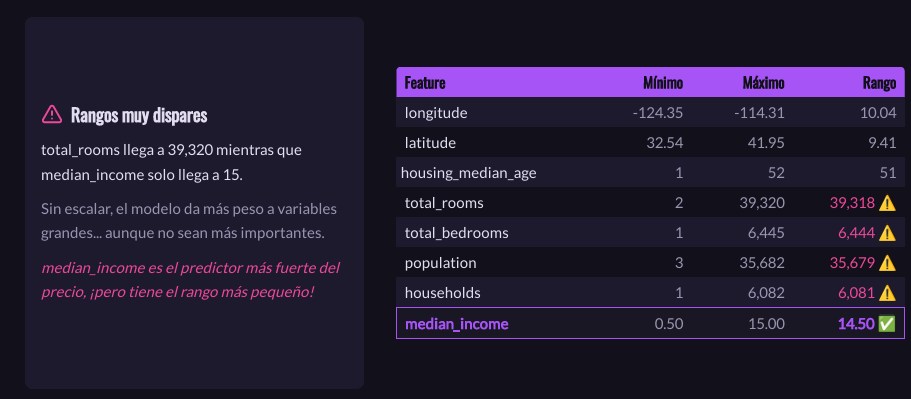

### Normalización

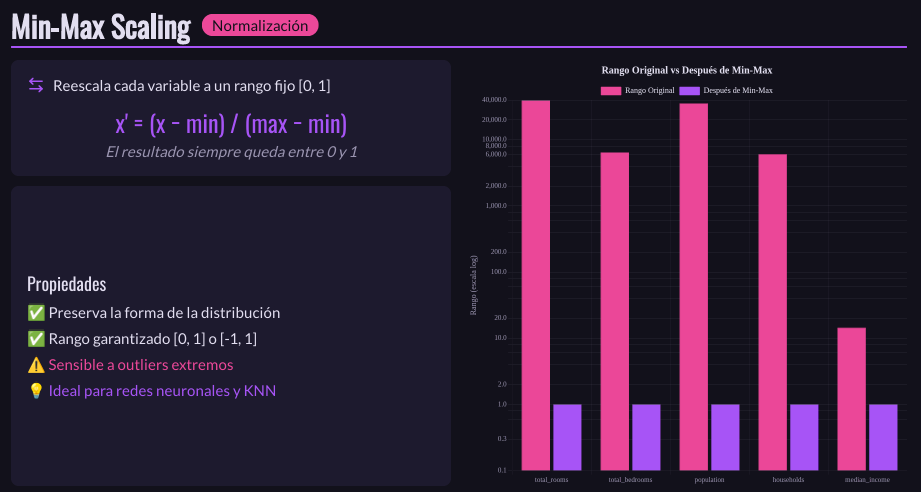

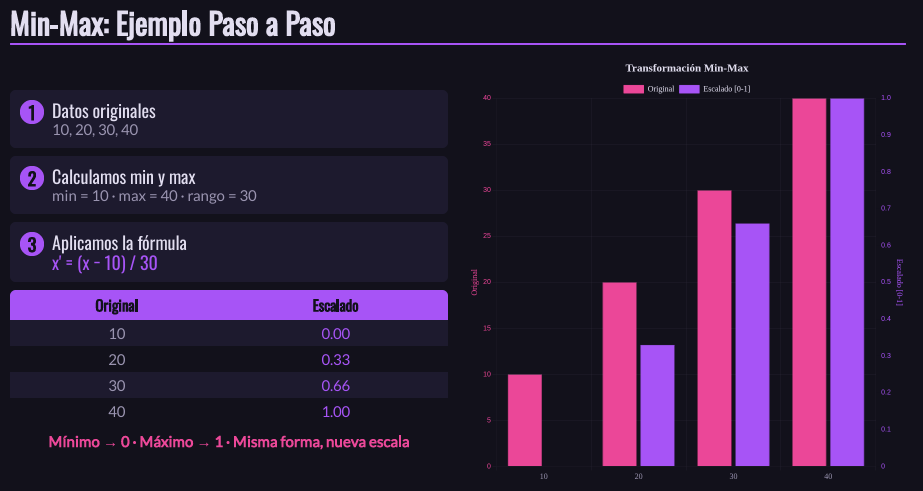

In [27]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1,1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num) # calcular y transformar

In [28]:
pd.DataFrame(housing_num_min_max_scaled, columns=housing_num.columns, index=housing_num.index)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-0.577689,0.134963,0.568627,-0.955339,-0.960273,-0.982118,-0.958888,0.079337
1,-0.575697,0.130712,-0.215686,-0.638995,-0.657045,-0.865579,-0.626048,0.076054
2,-0.579681,0.128587,1.000000,-0.925479,-0.941341,-0.972365,-0.942115,-0.067944
3,-0.581673,0.128587,1.000000,-0.935297,-0.927374,-0.968889,-0.928301,-0.290603
4,-0.581673,0.128587,1.000000,-0.917341,-0.913408,-0.968497,-0.915146,-0.538448
...,...,...,...,...,...,...,...,...
20635,-0.350598,0.475027,-0.058824,-0.915408,-0.884233,-0.952801,-0.891794,-0.853740
20636,-0.374502,0.477152,-0.333333,-0.964647,-0.953755,-0.980212,-0.962835,-0.716294
20637,-0.376494,0.464400,-0.372549,-0.885447,-0.849783,-0.943720,-0.857918,-0.834471
20638,-0.396414,0.464400,-0.333333,-0.905489,-0.873371,-0.958631,-0.885545,-0.811409


## Otra forma

### Estandarización

Transforma una variable para que tenga una media en 0 y una desviación estándar igual a 1.
Esta forma es menos subcetible a los outlier aun le van a afectar pero no tanto. Con valores muy extremos si va a ser subceptible.

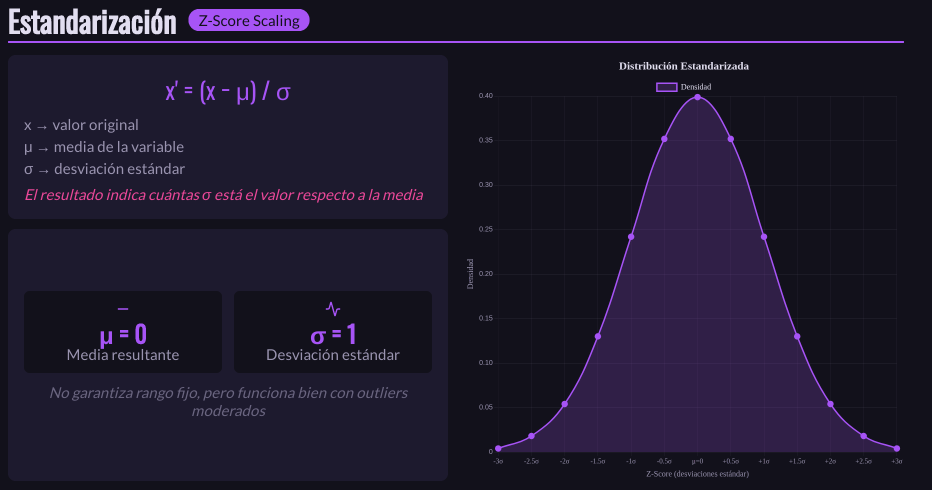

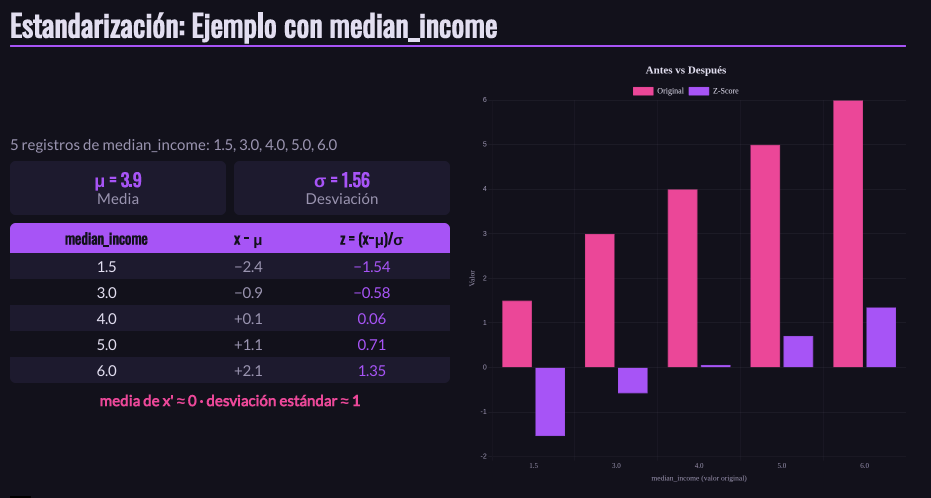

In [29]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

In [30]:
pd.DataFrame(housing_num_std_scaled, columns=housing_num.columns, index=housing_num.index)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-1.327835,1.052548,0.982143,-0.804819,-0.970325,-0.974429,-0.977033,2.344766
1,-1.322844,1.043185,-0.607019,2.045890,1.348276,0.861439,1.669961,2.332238
2,-1.332827,1.038503,1.856182,-0.535746,-0.825561,-0.820777,-0.843637,1.782699
3,-1.337818,1.038503,1.856182,-0.624215,-0.718768,-0.766028,-0.733781,0.932968
4,-1.337818,1.038503,1.856182,-0.462404,-0.611974,-0.759847,-0.629157,-0.012881
...,...,...,...,...,...,...,...,...
20635,-0.758826,1.801647,-0.289187,-0.444985,-0.388895,-0.512592,-0.443449,-1.216128
20636,-0.818722,1.806329,-0.845393,-0.888704,-0.920488,-0.944405,-1.008420,-0.691593
20637,-0.823713,1.778237,-0.924851,-0.174995,-0.125472,-0.369537,-0.174042,-1.142593
20638,-0.873626,1.778237,-0.845393,-0.355600,-0.305834,-0.604429,-0.393753,-1.054583


## Heavy tail

Como los outlier distorcionan todo cuando se aplique una normalización a datos va a distorcinar el escalamiento y lo mismo pasa con la estándarización. Para eso se aplica una transformación de los datos.

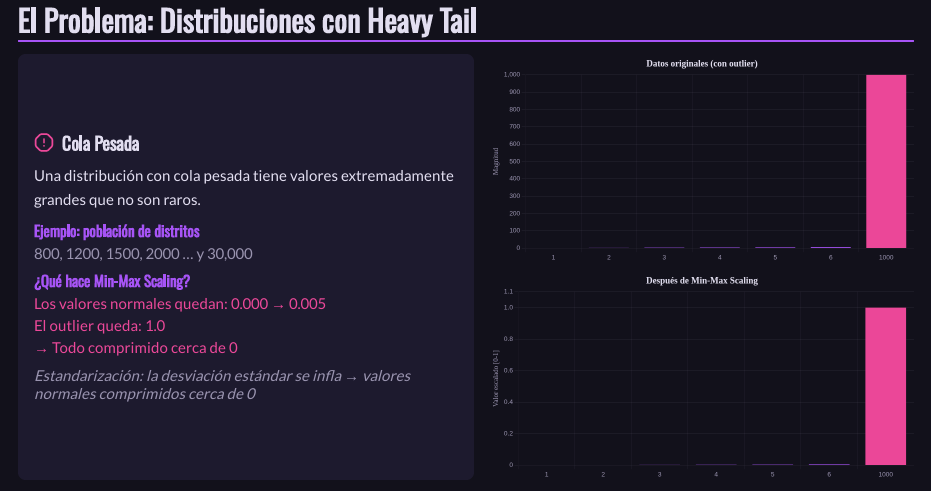

### Distribución campana vs distribución power law

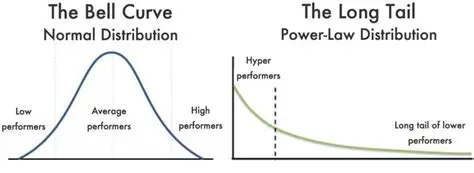

## Transformaciones mátematicas

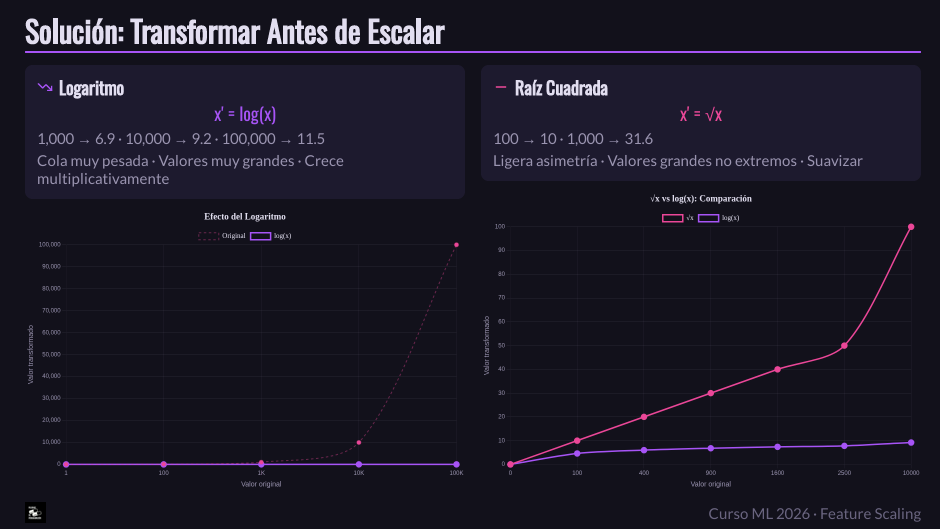

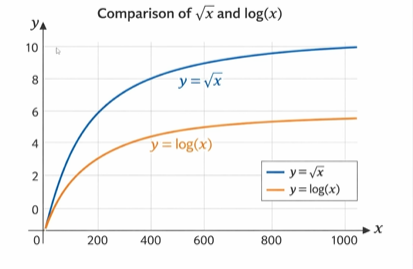

Con le logaritmo se va a acercar a una forma de campana.

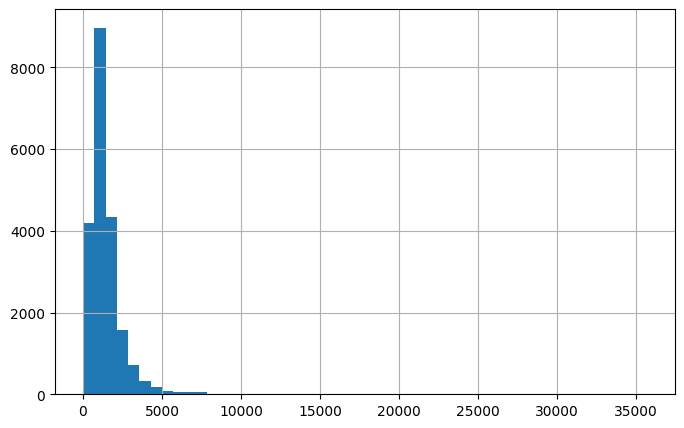

In [31]:
df_california_housing["population"].hist(bins=50, figsize=(8,5))
plt.show()

In [32]:
df_california_housing["population_sqrt"] = df_california_housing["population"].pow(0.5)
df_california_housing["population_log"] = df_california_housing["population"].transform("log")

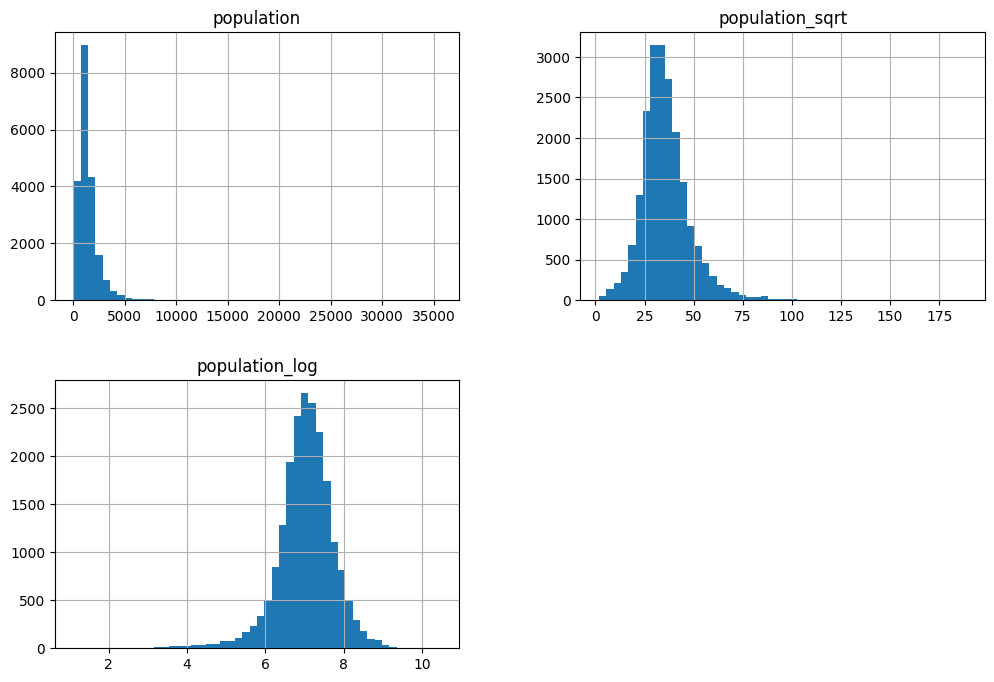

In [33]:
df_california_housing[
    ["population", "population_sqrt", "population_log"]
].hist(bins=50, figsize=(12,8))

plt.show()

## ¿cuando usar raíz y cuando log?

- Raíz se va a utilizar cunado hay una pequeña asimetria a la derecha. Los valores grandes no son exagerados. Cuando pasa eso es mejor trabajar con los log.